In [205]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb

from shared.database_file.set_up import Setup


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [145]:

connector = Setup().get_duckdb_conn()
fact_flight = connector.query("""SELECT *
                                 FROM vayora_dw.fact_flight ff
                                 JOIN vayora_dw.dim_pilot dp ON dp.dim_pilot_sk = ff.fact_flight_pilot
                                 JOIN vayora_dw.dim_takeoff dt ON dt.dim_takeoff_sk = ff.fact_flight_takeoff
                                 JOIN vayora_dw.dim_weather dw on dw.dim_weather_sk = ff.fact_flight_weather
                                 JOIN vayora_dw.dim_date dd ON dd.date_key = ff.fact_flight_start_date
                                 JOIN vayora_dw.dim_time dtm on dtm.time_key = ff.fact_flight_start_time
                              """
                              ).df()

In [146]:
cols = fact_flight.columns.difference(['fact_flight_bk', 'fact_flight_sk'])
fact_flight = fact_flight.drop_duplicates(subset=cols, keep='first')

In [147]:
weather_df = connector.query("""SELECT * FROM weather.weather_historic dw""").df()

In [167]:
fact_flight.info()

<class 'pandas.DataFrame'>
Index: 33670 entries, 0 to 99983
Data columns (total 77 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   fact_flight_sk              33670 non-null  int32         
 1   fact_flight_bk              33670 non-null  int32         
 2   fact_flight_distance        33670 non-null  int32         
 3   fact_flight_airtime         33670 non-null  object        
 4   fact_flight_pilot           33670 non-null  int32         
 5   fact_flight_takeoff         33670 non-null  int32         
 6   fact_flight_weather         33670 non-null  int32         
 7   fact_flight_start_date      33670 non-null  int32         
 8   fact_flight_start_time      33670 non-null  int32         
 9   dim_pilot_sk                33670 non-null  int32         
 10  dim_pilot_bk                33670 non-null  int32         
 11  dim_pilot_maxdistance       33670 non-null  int32         
 12  dim_pi

In [168]:
fact_flight = fact_flight.rename(columns={"dim_takeoff_name": "takeoff"})
weather_df = weather_df.rename(columns={"weather_place": "takeoff", "weather_date" : "time"})

In [169]:
fact_flight["datetime"] = pd.to_datetime(fact_flight["full_date"].astype(str) + " " + fact_flight["full_time"].astype(str))
weather_df["time"] = pd.to_datetime(weather_df["time"])

In [170]:
fact_flight = fact_flight.rename(columns={"datetime": "time"})

In [186]:
flight_df = fact_flight.filter(regex="wind|precip|^takeoff$|^time$|_date|itutde$")

In [187]:
flight_df["flyable"] = 1

In [15]:
weather_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3077568 entries, 0 to 3077567
Data columns (total 38 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   weather_id                  int32         
 1   weather_date                datetime64[us]
 2   temperature_2m              float64       
 3   boundary_layer_height       Int32         
 4   lifted_index                float64       
 5   convective_inhibition       Int32         
 6   cloud_cover                 float64       
 7   cloud_cover_low             float64       
 8   cloud_cover_mid             float64       
 9   cloud_cover_high            float64       
 10  wind_direction_120m         float64       
 11  wind_speed_120m             float64       
 12  precipitation               float64       
 13  precipitation_probability   float64       
 14  temperature_120m            float64       
 15  pressure_msl                float64       
 16  surface_pressure            f

In [162]:
weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 3077568 entries, 0 to 3077567
Data columns (total 16 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   time                       datetime64[us]
 1   wind_direction_120m        float64       
 2   wind_speed_120m            float64       
 3   precipitation              float64       
 4   precipitation_probability  float64       
 5   wind_speed_950hpa          float64       
 6   wind_speed_850hpa          float64       
 7   wind_speed_800hpa          float64       
 8   wind_speed_700hpa          float64       
 9   wind_direction_950hpa      float64       
 10  wind_direction_850hpa      float64       
 11  wind_direction_800hpa      float64       
 12  wind_direction_700hpa      float64       
 13  wind_direction_600hpa      float64       
 14  wind_speed_600hpa          float64       
 15  takeoff                    str           
dtypes: datetime64[us](1), float64(14), str(1)
memor

In [128]:
weather = weather_df.filter(regex="wind|precip|^takeoff$|time|date")

In [189]:
flight_df.info()

<class 'pandas.DataFrame'>
Index: 33670 entries, 0 to 99983
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   takeoff                33670 non-null  str           
 1   wind_direction_120m    33670 non-null  float64       
 2   wind_speed_120m        33670 non-null  float64       
 3   precipitation          33670 non-null  float64       
 4   wind_speed_950hpa      33670 non-null  float64       
 5   wind_speed_850hpa      33670 non-null  float64       
 6   wind_speed_800hpa      33670 non-null  float64       
 7   wind_speed_700hpa      33670 non-null  float64       
 8   wind_direction_950hpa  33670 non-null  float64       
 9   wind_direction_850hpa  33670 non-null  float64       
 10  wind_direction_800hpa  33670 non-null  float64       
 11  wind_direction_700hpa  33670 non-null  float64       
 12  wind_direction_600hpa  33670 non-null  float64       
 13  wind_speed_600hpa

In [188]:
flight_df.drop(["fact_flight_start_date", "full_date", "precipitation_probability"], axis=1, inplace=True)

In [190]:
flight_df = weather.merge(
    flight_df,
    on=["time", "takeoff"],
    how="left"
)

In [191]:
flight_df["flyable"] = flight_df["flyable"].fillna(0)

In [198]:
flight_df

,time,wind_direction_120m_x,wind_speed_120m_x,precipitation_x,precipitation_probability,wind_speed_950hpa_x,wind_speed_850hpa_x,wind_speed_800hpa_x,wind_speed_700hpa_x,wind_direction_950hpa_x,...,wind_speed_850hpa_y,wind_speed_800hpa_y,wind_speed_700hpa_y,wind_direction_950hpa_y,wind_direction_850hpa_y,wind_direction_800hpa_y,wind_direction_700hpa_y,wind_direction_600hpa_y,wind_speed_600hpa_y,flyable
0,2022-01-01 00:00:00,235.36,24.56,0.0,NaN,41.42,41.47,44.10,54.97,254.28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,2022-01-01 01:00:00,220.70,24.23,0.0,NaN,37.65,43.94,46.33,57.96,255.11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,2022-01-01 02:00:00,225.58,25.72,0.0,NaN,37.42,41.48,43.73,55.27,245.56,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,2022-01-01 03:00:00,220.10,27.38,0.0,NaN,36.59,36.00,40.11,54.08,240.18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,2022-01-01 04:00:00,216.03,29.99,0.0,NaN,34.70,33.29,41.11,52.89,231.34,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3092258,2024-12-31 19:00:00,206.00,45.56,0.0,NaN,77.22,76.61,71.03,65.25,242.54,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3092259,2024-12-31 20:00:00,204.00,45.93,0.0,NaN,83.24,77.30,73.38,69.14,248.45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3092260,2024-12-31 21:00:00,211.00,51.44,0.0,NaN,85.55,78.97,75.17,73.18,247.38,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3092261,2024-12-31 22:00:00,207.00,52.54,0.0,NaN,86.97,82.89,75.76,76.63,239.21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [199]:
balanced = []

for city, group in flight_df.groupby("takeoff"):
    fly = group[group["flyable"] == 1]
    nofly = group[(group["flyable"] == 0) & (group["wind_speed_120m_x"] >= 35)]

    n_vols = len(fly)
    n_dispo = len(nofly)

    if n_vols == 0:
        continue # Rien à équilibrer s'il n'y a pas de vols

    # STRATÉGIE : Si on a assez de stock, on pioche sans remise.
    # Sinon, on pioche avec remise (replace=True).
    do_replace = n_dispo < n_vols

    try:
        if n_dispo > 0:
            nofly_sample = nofly.sample(
                n=n_vols,
                replace=do_replace,
                random_state=42
            )
            balanced.append(pd.concat([fly, nofly_sample]))
        else:
            print(f"⚠️ Alerte : Le site {city} n'a aucune donnée 'tempête' disponible.")

    except Exception as e:
        print(f"❌ Erreur sur le site {city}: {e}")

df_balanced = pd.concat(balanced)

In [203]:
df_balanced = df_balanced.drop(['precipitation_probability'], axis=1)

In [204]:
df_balanced.info()

<class 'pandas.DataFrame'>
Index: 67340 entries, 489672 to 257489
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   time                     67340 non-null  datetime64[us]
 1   wind_direction_120m_x    67340 non-null  float64       
 2   wind_speed_120m_x        67340 non-null  float64       
 3   precipitation_x          67340 non-null  float64       
 4   wind_speed_950hpa_x      67340 non-null  float64       
 5   wind_speed_850hpa_x      67340 non-null  float64       
 6   wind_speed_800hpa_x      67340 non-null  float64       
 7   wind_speed_700hpa_x      67340 non-null  float64       
 8   wind_direction_950hpa_x  67340 non-null  float64       
 9   wind_direction_850hpa_x  67340 non-null  float64       
 10  wind_direction_800hpa_x  67340 non-null  float64       
 11  wind_direction_700hpa_x  67340 non-null  float64       
 12  wind_direction_600hpa_x  67340 non-null  f

In [201]:
df_balanced = df_balanced.filter(regex=r'^(?!.*_y$)')

In [206]:


# --- ÉTAPE 1 : Calcul de l'orientation de référence par décollage ---
def get_circular_mean(series):
    # On passe en radians
    rads = np.radians(series)
    # Moyenne des vecteurs
    sin_mean = np.nanmean(np.sin(rads))
    cos_mean = np.nanmean(np.cos(rads))
    # Retour en degrés (0-360)
    res = np.degrees(np.arctan2(sin_mean, cos_mean))
    return res % 360

# On calcule la référence sur les jours où flyable == 1 (les vrais décollages)
deco_ref = df_balanced[df_balanced['flyable'] == 1].groupby('takeoff')['wind_direction_120m_x'].apply(get_circular_mean)

# On injecte cette référence dans le DF principal
df_balanced['deco_orientation_ref'] = df_balanced['takeoff'].map(deco_ref)

# --- ÉTAPE 2 : Calcul de l'écart angulaire ---
def get_angle_diff(a, b):
    diff = np.abs(a - b)
    return np.where(diff > 180, 360 - diff, diff)

df_balanced['wind_diff_ref'] = get_angle_diff(df_balanced['wind_direction_120m_x'],
                                              df_balanced['deco_orientation_ref'])


In [217]:
deco_ref

takeoff
aiguebelette            290.212093
allevard                308.779922
andenne                  36.841771
argeliers               115.933520
aubas                   348.968479
                           ...    
terril du levant         26.598539
treh                    250.890547
velars est               43.883252
vierville sur mer        37.853722
volmerange les mines     91.775152
Name: wind_direction_120m_x, Length: 111, dtype: float64

In [212]:
df_balanced.loc[df_balanced['wind_diff_ref'] > 70, 'flyable'] = 0

# Vérifions combien de lignes ont été "corrigées"
nb_modifs = len(df_balanced[df_balanced['wind_diff_ref'] > 70])
print(f"Nombre de vols forcés en 'Non-volable' (>70°): {nb_modifs}")

Nombre de vols forcés en 'Non-volable' (>70°): 30394


In [213]:
# Choix des features (on prend tout ce qui est numérique sauf la cible et les métadonnées)
features = [
    'wind_speed_120m_x', 'precipitation_x', 'wind_diff_ref',
    'wind_speed_950hpa_x', 'wind_speed_850hpa_x', 'wind_speed_800hpa_x',
    'wind_speed_700hpa_x', 'wind_speed_600hpa_x'
]

X = df_balanced[features]
y = df_balanced['flyable']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)


y_pred = model.predict(X_test)
print(f"Précision globale : {accuracy_score(y_test, y_pred):.2%}")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred))

Précision globale : 99.96%

Rapport de classification :
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      8078
         1.0       1.00      1.00      1.00      5390

    accuracy                           1.00     13468
   macro avg       1.00      1.00      1.00     13468
weighted avg       1.00      1.00      1.00     13468



In [211]:
df_balanced[df_balanced['takeoff'] == "volmerange les mines"]

,time,wind_direction_120m_x,wind_speed_120m_x,precipitation_x,wind_speed_950hpa_x,wind_speed_850hpa_x,wind_speed_800hpa_x,wind_speed_700hpa_x,wind_direction_950hpa_x,wind_direction_850hpa_x,wind_direction_800hpa_x,wind_direction_700hpa_x,wind_direction_600hpa_x,wind_speed_600hpa_x,takeoff,flyable,deco_orientation_ref,wind_diff_ref
257028,2022-01-18 16:00:00,70.75,24.52,0.0,37.75,43.83,43.64,37.91,84.11,98.97,94.60,87.18,98.88,26.50,volmerange les mines,1.0,91.775152,21.025152
257145,2022-01-23 13:00:00,80.79,13.77,0.0,17.63,15.59,16.29,29.67,81.16,74.74,72.12,74.22,79.16,39.15,volmerange les mines,1.0,91.775152,10.985152
257146,2022-01-23 14:00:00,81.03,14.14,0.0,17.14,14.19,15.30,28.04,83.52,84.47,78.69,84.92,76.26,37.90,volmerange les mines,1.0,91.775152,10.745152
257147,2022-01-23 15:00:00,82.41,16.68,0.0,18.52,12.30,13.58,26.10,79.16,90.00,83.66,92.73,74.74,37.31,volmerange les mines,1.0,91.775152,9.365152
257148,2022-01-23 15:00:00,82.41,16.68,0.0,18.52,12.30,13.58,26.10,79.16,90.00,83.66,92.73,74.74,37.31,volmerange les mines,1.0,91.775152,9.365152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281829,2024-11-19 11:00:00,234.00,61.36,1.5,56.26,109.80,10.30,10.10,229.19,246.52,251.64,255.88,259.13,10.40,volmerange les mines,0.0,91.775152,142.224848
270474,2023-08-06 18:00:00,287.80,42.07,0.0,51.59,79.00,73.60,54.20,296.76,309.38,306.71,299.50,307.63,49.59,volmerange les mines,0.0,91.775152,163.975152
276141,2024-03-28 11:00:00,240.26,50.36,0.2,35.34,66.13,67.40,81.05,227.22,240.26,240.07,243.63,242.86,73.55,volmerange les mines,0.0,91.775152,148.484848
282468,2024-12-16 01:00:00,242.00,36.74,0.0,64.26,59.13,54.44,50.80,269.31,283.82,290.38,305.05,313.70,50.92,volmerange les mines,0.0,91.775152,150.224848


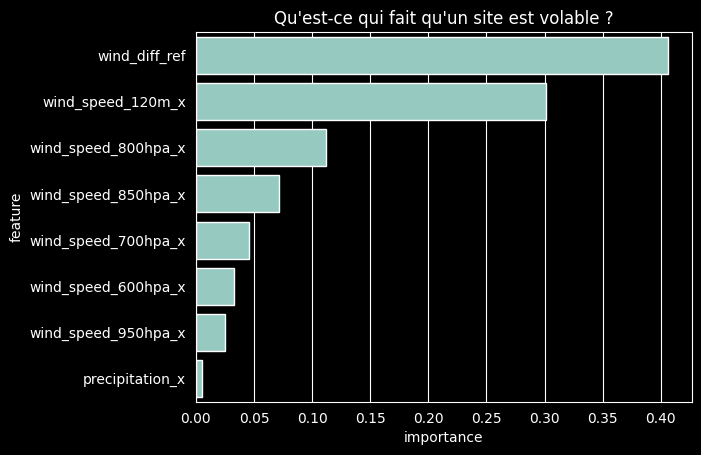

In [214]:


importance = pd.DataFrame({'feature': features, 'importance': model.feature_importances_})
sns.barplot(x='importance', y='feature', data=importance.sort_values('importance', ascending=False))
plt.title("Qu'est-ce qui fait qu'un site est volable ?")
plt.show()

In [216]:
import joblib

# Sauvegarder le modèle Random Forest
joblib.dump(model, 'model_parapente.pkl')

# Sauvegarder le dictionnaire des orientations (très important !)
# deco_ref est la Series Pandas que l'on a calculée avec la médiane circulaire
deco_ref.to_pickle('orientations_sites.pkl')